In [111]:
from pathlib import Path

import numpy as np
import pandas as pd
from scipy.optimize import linear_sum_assignment
from scipy.spatial.distance import cdist

import matplotlib.pyplot as plt

In [112]:
PROJECT_ROOT = Path.cwd().parent

DATA_ROOT = PROJECT_ROOT / "data/sample"

SAMPLE_ID = "44b6_0113de3b"

PROCESSED_DIR = (
        DATA_ROOT
        / "processed"
        / "stage_7_processed_dataset"
        / SAMPLE_ID
)

FEATURE_DIR = PROCESSED_DIR / "feature_extraction"

In [113]:
feature_files = sorted(FEATURE_DIR.glob("t*.csv"))

detections = [
    pd.read_csv(file)
    for file in feature_files
]

print(f"Loaded {len(detections)} timepoints.")

Loaded 20 timepoints.


In [114]:
detections[0].head()

,cell_id,centroid_z,centroid_y,centroid_x,volume_voxels,z_min,y_min,x_min,z_max,y_max,...,intensity_median,intensity_std,intensity_min,intensity_max,intensity_q25,intensity_q75,intensity_sum,intensity_range,intensity_iqr,intensity_cv
0,1,0.231183,6.354839,52.204301,186.0,0,0,46,2,14,...,941.0,296.678929,587,1792,809.25,1182.00,191212,1205,372.75,0.288592
1,2,0.153153,6.815315,71.774775,222.0,0,0,65,2,16,...,1102.5,183.527683,773,1534,950.50,1247.50,246984,761,297.00,0.164963
2,3,0.320833,26.012500,65.191667,240.0,0,18,59,4,35,...,1026.0,285.671969,729,1744,893.75,1363.75,271937,1015,470.00,0.252122
3,4,1.074627,62.743555,58.230665,737.0,0,55,48,4,72,...,1344.0,433.686663,601,2397,1000.00,1726.00,1019175,1796,726.00,0.313614
4,5,0.364431,98.571429,34.836735,343.0,0,89,28,2,109,...,925.0,208.344722,582,1407,780.00,1102.00,323930,825,322.00,0.220610


In [115]:
for t, df in enumerate(detections):
    print(f"t={t:03d}: {len(df)} cells")

t=000: 202 cells
t=001: 211 cells
t=002: 209 cells
t=003: 214 cells
t=004: 211 cells
t=005: 199 cells
t=006: 207 cells
t=007: 209 cells
t=008: 205 cells
t=009: 206 cells
t=010: 209 cells
t=011: 208 cells
t=012: 215 cells
t=013: 220 cells
t=014: 222 cells
t=015: 222 cells
t=016: 206 cells
t=017: 211 cells
t=018: 213 cells
t=019: 224 cells


In [116]:
centroids = df[
    [
        "centroid_z",
        "centroid_y",
        "centroid_x",
    ]
].to_numpy()
volumes = df["volume_voxels"].to_numpy()

In [117]:
tracks_data = []

for df in detections:
    tracks_data.append({
        "centroids": df[
            ["centroid_z", "centroid_y", "centroid_x"]
        ].to_numpy(),

        "volumes": df["volume_voxels"].to_numpy(),

        "intensity_mean": df["intensity_mean"].to_numpy(),
        "intensity_std": df["intensity_std"].to_numpy(),

        "detections": df,
    })

In [118]:
from scipy.spatial.distance import cdist

t = 0

detections_t = detections[t]
detections_tp1 = detections[t + 1]

centroids_t = detections_t[
    ["centroid_z", "centroid_y", "centroid_x"]
].to_numpy(dtype=np.float64)

centroids_tp1 = detections_tp1[
    ["centroid_z", "centroid_y", "centroid_x"]
].to_numpy(dtype=np.float64)

cost_matrix = cdist(
    centroids_t,
    centroids_tp1,
    metric="euclidean",
)

print(f"Frame {t}: {len(centroids_t)} cells")
print(f"Frame {t + 1}: {len(centroids_tp1)} cells")
print(f"Cost matrix shape: {cost_matrix.shape}")

Frame 0: 202 cells
Frame 1: 211 cells
Cost matrix shape: (202, 211)


In [119]:
print(f"Minimum distance : {cost_matrix.min():.2f}")
print(f"Mean distance    : {cost_matrix.mean():.2f}")
print(f"Maximum distance : {cost_matrix.max():.2f}")

Minimum distance : 0.85
Mean distance    : 125.61
Maximum distance : 320.67


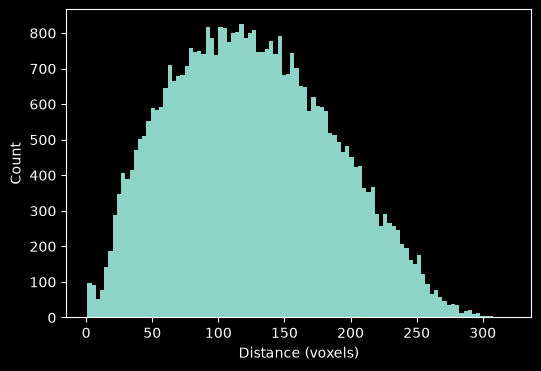

In [120]:
plt.figure(figsize=(6, 4))

plt.hist(cost_matrix.ravel(), bins=100)

plt.xlabel("Distance (voxels)")
plt.ylabel("Count")

plt.show()

In [121]:
from scipy.optimize import linear_sum_assignment

row_ind, col_ind = linear_sum_assignment(cost_matrix)

print(f"Matched pairs: {len(row_ind)}")

Matched pairs: 202


In [122]:
matched_distances = cost_matrix[row_ind, col_ind]

print(f"Minimum : {matched_distances.min():.2f}")
print(f"Mean    : {matched_distances.mean():.2f}")
print(f"Maximum : {matched_distances.max():.2f}")

Minimum : 0.85
Mean    : 4.95
Maximum : 38.66


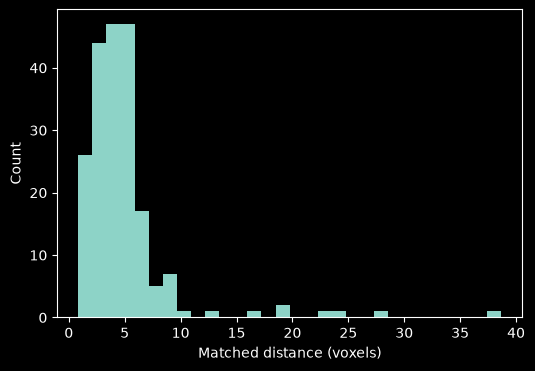

In [123]:
plt.figure(figsize=(6, 4))

plt.hist(matched_distances, bins=30)

plt.xlabel("Matched distance (voxels)")
plt.ylabel("Count")

plt.show()

In [124]:
matches = pd.DataFrame({
    "cell_t": row_ind,
    "cell_t1": col_ind,
    "distance": matched_distances,
})

matches.sort_values(
    "distance",
    ascending=False,
).head(20)

,cell_t,cell_t1,distance
12,12,32,38.655033
82,82,38,27.596625
77,77,53,23.825841
50,50,202,22.691707
48,48,24,19.501111
18,18,10,19.004823
94,94,85,16.405127
121,121,123,12.272538
117,117,132,10.603824
100,100,104,9.638248


In [125]:
MAX_DISTANCE = 12.0

accepted_matches = matches[
    matches["distance"] <= MAX_DISTANCE
    ].copy()

rejected_matches = matches[
    matches["distance"] > MAX_DISTANCE
    ].copy()

In [126]:
print(f"Total assignments : {len(matches)}")
print(f"Accepted          : {len(accepted_matches)}")
print(f"Rejected          : {len(rejected_matches)}")

Total assignments : 202
Accepted          : 194
Rejected          : 8


In [127]:
matched_prev = set(accepted_matches["cell_t"])
matched_next = set(accepted_matches["cell_t1"])

unmatched_prev = sorted(
    set(range(len(detections[0]))) - matched_prev
)

unmatched_next = sorted(
    set(range(len(detections[1]))) - matched_next
)
print(f"Matched previous : {len(matched_prev)}")
print(f"Matched next     : {len(matched_next)}")
print(f"Unmatched prev   : {len(unmatched_prev)}")
print(f"Unmatched next   : {len(unmatched_next)}")

Matched previous : 194
Matched next     : 194
Unmatched prev   : 8
Unmatched next   : 17


In [128]:
import numpy as np
import pandas as pd
from scipy.optimize import linear_sum_assignment
from scipy.spatial.distance import cdist

MAX_DISTANCE = 12.0

# -----------------------------
# Cost function weights
# -----------------------------
W_DISTANCE = 0.8
W_VOLUME = 0.2
W_INTENSITY = 0.10

W_INTENSITY_MEAN = 0.70
W_INTENSITY_STD = 0.30

# Reject matches whose volumes differ by more than this ratio
MAX_VOLUME_RATIO = 1.5

# Number of times to re-estimate the global shift using the current
# set of accepted matches before finalizing assignment for a frame pair.
SHIFT_REFINE_ITERS = 3


def robust_shift(coords0, coords1, rows=None, cols=None):
    """
    Estimate the global shift between two point sets.

    If `rows`/`cols` (matched pairs from a previous assignment pass) are
    supplied, the shift is the median displacement over just those
    matched pairs. This is robust to any cells that are new, lost, or
    otherwise didn't match last pass, since they're simply excluded.

    Otherwise, falls back to a coarse median-of-all-points estimate,
    which is already far less sensitive than a mean to a few new/lost
    cells (mitosis, cells entering/leaving the field of view, spurious
    detections, etc.).
    """
    if rows is not None and len(rows) > 0:
        disp = coords1[cols] - coords0[rows]
        return np.median(disp, axis=0)

    return np.median(coords1, axis=0) - np.median(coords0, axis=0)


def assign(coords0_shifted, coords1, detections0, detections1):
    """
    Build the assignment cost matrix using
    - centroid distance
    - volume similarity
    - intensity similarity

    Invalid matches are rejected using distance and volume constraints.
    """

    # ---------------------------------------------------------
    # Distance
    # ---------------------------------------------------------
    distance_matrix = cdist(coords0_shifted, coords1)

    distance_cost = distance_matrix / MAX_DISTANCE

    # ---------------------------------------------------------
    # Volume
    # ---------------------------------------------------------
    volume_cost = (
            np.abs(vol0[:, None] - vol1[None, :])
            / np.maximum(vol0[:, None], vol1[None, :])
    )

    volume_ratio = (
            np.maximum(vol0[:, None], vol1[None, :])
            / np.minimum(vol0[:, None], vol1[None, :])
    )

    # ---------------------------------------------------------
    # Intensity
    # ---------------------------------------------------------
    mean0 = detections0["intensity_mean"].to_numpy(dtype=float)
    mean1 = detections1["intensity_mean"].to_numpy(dtype=float)

    std0 = detections0["intensity_std"].to_numpy(dtype=float)
    std1 = detections1["intensity_std"].to_numpy(dtype=float)

    EPS = 1e-8

    mean_cost = (
            np.abs(mean0[:, None] - mean1[None, :])
            / (np.maximum(mean0[:, None], mean1[None, :]) + EPS)
    )

    std_cost = (
            np.abs(std0[:, None] - std1[None, :])
            / (np.maximum(std0[:, None], std1[None, :]) + EPS)
    )

    intensity_cost = (
            W_INTENSITY_MEAN * mean_cost +
            W_INTENSITY_STD * std_cost
    )

    # ---------------------------------------------------------
    # Final Cost
    # ---------------------------------------------------------
    cost_matrix = (
            W_DISTANCE * distance_cost +
            W_VOLUME * volume_cost +
            W_INTENSITY * intensity_cost
    )

    # ---------------------------------------------------------
    # Reject impossible matches
    # ---------------------------------------------------------
    invalid = (
            (distance_matrix > MAX_DISTANCE)
            | (volume_ratio > MAX_VOLUME_RATIO)
    )

    cost_matrix = np.where(
        invalid,
        1e6,
        cost_matrix,
    )

    rows, cols = linear_sum_assignment(cost_matrix)

    valid = ~invalid[rows, cols]

    return (
        rows[valid],
        cols[valid],
        distance_matrix,
    )


# ------------------------------------------------------------
# Initialize tracks using the first frame
# ------------------------------------------------------------

current_track_ids = np.arange(len(detections[0]), dtype=int)
next_track_id = len(current_track_ids)

tracks = []

for cell, track in enumerate(current_track_ids):

    row = detections[0].iloc[cell]

    tracks.append({
        "track_id": track,
        "frame": 0,
        "cell": cell,
        "z": row["centroid_z"],
        "y": row["centroid_y"],
        "x": row["centroid_x"],
        "volume": row["volume_voxels"],
    })

# ------------------------------------------------------------
# Process every pair of frames
# ------------------------------------------------------------

for t in range(len(detections) - 1):

    det0 = detections[t]
    det1 = detections[t + 1]

    # -----------------------------
    # Coordinates / volumes
    # -----------------------------

    coords0 = det0[
        ["centroid_z", "centroid_y", "centroid_x"]
    ].to_numpy(dtype=float)

    coords1 = det1[
        ["centroid_z", "centroid_y", "centroid_x"]
    ].to_numpy(dtype=float)

    vol0 = det0["volume_voxels"].to_numpy(dtype=float)
    vol1 = det1["volume_voxels"].to_numpy(dtype=float)

    detections0 = tracks_data[t]["detections"]
    detections1 = tracks_data[t + 1]["detections"]

    # -----------------------------
    # Estimate global motion, then refine it using the cells that
    # actually matched last pass. This stops a handful of divergent
    # cells (new/lost cells, noise, mitosis) from biasing the shift
    # estimate used for every other cell in the frame.
    # -----------------------------

    global_shift = robust_shift(coords0, coords1)
    rows, cols, distance_matrix = np.array([], dtype=int), np.array([], dtype=int), None

    for _ in range(SHIFT_REFINE_ITERS):

        predicted_coords0 = coords0 + global_shift

        rows, cols, distance_matrix = assign(
            predicted_coords0,
            coords1,
            detections0,
            detections1,
        )

        if len(rows) == 0:
            break

        refined_shift = robust_shift(coords0, coords1, rows, cols)

        converged = np.allclose(refined_shift, global_shift, atol=1e-3)
        global_shift = refined_shift

        if converged:
            break

    print(
        f"Frame {t}->{t+1} "
        f"shift = ({global_shift[0]:.2f}, "
        f"{global_shift[1]:.2f}, "
        f"{global_shift[2]:.2f})"
    )

    # -----------------------------
    # Matches are already filtered for distance/volume validity
    # inside assign(), so no further thresholding is needed here.
    # -----------------------------

    accepted = pd.DataFrame({
        "cell_t": rows,
        "cell_t1": cols,
        "distance": distance_matrix[rows, cols] if len(rows) else [],
    })

    next_track_ids = np.full(
        len(det1),
        -1,
        dtype=int,
    )

    # --------------------------------------------------------
    # Continue existing tracks
    # --------------------------------------------------------

    for _, row in accepted.iterrows():

        prev_cell = int(row.cell_t)
        next_cell = int(row.cell_t1)

        next_track_ids[next_cell] = current_track_ids[prev_cell]

    # --------------------------------------------------------
    # Start new tracks
    # --------------------------------------------------------

    for cell in np.where(next_track_ids == -1)[0]:

        next_track_ids[cell] = next_track_id
        next_track_id += 1

    # --------------------------------------------------------
    # Save tracks
    # --------------------------------------------------------

    for cell, track in enumerate(next_track_ids):

        row = det1.iloc[cell]

        tracks.append({
            "track_id": track,
            "frame": t + 1,
            "cell": cell,
            "z": row["centroid_z"],
            "y": row["centroid_y"],
            "x": row["centroid_x"],
            "volume": row["volume_voxels"],
        })

    print(
        f"{t:03d}->{t+1:03d} : "
        f"{len(accepted):3d} matches | "
        f"{len(det1) - len(accepted):2d} new tracks"
    )

    current_track_ids = next_track_ids

tracks = pd.DataFrame(tracks)

Frame 0->1 shift = (0.68, 2.99, 1.91)
000->001 : 169 matches | 42 new tracks
Frame 1->2 shift = (0.85, 0.91, 0.78)
001->002 : 172 matches | 37 new tracks
Frame 2->3 shift = (0.84, 1.79, 3.87)
002->003 : 165 matches | 49 new tracks
Frame 3->4 shift = (1.19, 2.39, 4.03)
003->004 : 172 matches | 39 new tracks
Frame 4->5 shift = (0.83, 1.99, 1.05)
004->005 : 168 matches | 31 new tracks
Frame 5->6 shift = (0.75, 4.36, -1.08)
005->006 : 118 matches | 89 new tracks
Frame 6->7 shift = (0.98, 2.39, 2.05)
006->007 : 171 matches | 38 new tracks
Frame 7->8 shift = (0.75, 2.84, 3.31)
007->008 : 178 matches | 27 new tracks
Frame 8->9 shift = (0.72, 3.26, 1.14)
008->009 : 174 matches | 32 new tracks
Frame 9->10 shift = (1.20, -2.11, 0.96)
009->010 : 179 matches | 30 new tracks
Frame 10->11 shift = (0.49, 4.44, 1.71)
010->011 : 158 matches | 50 new tracks
Frame 11->12 shift = (0.26, 8.09, -0.15)
011->012 : 179 matches | 36 new tracks
Frame 12->13 shift = (-0.34, 5.64, -3.64)
012->013 : 175 matches | 4

In [129]:
import pandas as pd

tracks = pd.DataFrame(tracks)

## Stage 7A — Gap closing / track stitching

In [130]:
# ============================================================
# Stage 7A — Gap closing / track stitching
# ============================================================
# Repairs "1 -> 0 -> 1" fragmentation: a track ends because a single
# frame's match was rejected (occlusion, missed segmentation, noise),
# and a "new" track starts a frame or two later that is really the
# same cell continuing. Stitches such fragments back into one
# track_id using position + volume similarity across the gap.

MAX_GAP = 2                 # max number of frames a track may vanish for
STITCH_MAX_DISTANCE = 15.0  # generous vs MAX_DISTANCE: spans >1 frame
STITCH_MAX_VOLUME_RATIO = 1.5


def stitch_tracks(tracks, max_gap=MAX_GAP,
                   max_distance=STITCH_MAX_DISTANCE,
                   max_volume_ratio=STITCH_MAX_VOLUME_RATIO):

    tracks = tracks.copy()
    last_frame = tracks["frame"].max()

    ends = (
        tracks.sort_values("frame")
        .groupby("track_id")
        .tail(1)
        .set_index("track_id")
    )
    starts = (
        tracks.sort_values("frame")
        .groupby("track_id")
        .head(1)
        .set_index("track_id")
    )

    # Candidate parents: tracks that end before the movie is over
    candidate_parents = ends[ends["frame"] < last_frame]
    # Candidate continuations: tracks that start after frame 0
    candidate_children = starts[starts["frame"] > 0]

    merges = {}  # child_track_id -> parent_track_id

    for parent_id, prow in candidate_parents.sort_values("frame").iterrows():

        window = candidate_children[
            (candidate_children["frame"] > prow["frame"]) &
            (candidate_children["frame"] <= prow["frame"] + max_gap) &
            (candidate_children.index != parent_id)
        ]
        if len(window) == 0:
            continue

        dist = np.sqrt(
            (window["z"] - prow["z"]) ** 2 +
            (window["y"] - prow["y"]) ** 2 +
            (window["x"] - prow["x"]) ** 2
        )
        vol_ratio = (
            np.maximum(window["volume"], prow["volume"])
            / np.minimum(window["volume"], prow["volume"])
        )

        ok = (dist <= max_distance) & (vol_ratio <= max_volume_ratio)
        candidates = dist[ok]
        if len(candidates) == 0:
            continue

        best_child = candidates.idxmin()

        if best_child in merges:
            continue  # fragment already claimed by an earlier-ending parent

        merges[best_child] = parent_id

    def resolve(track_id, _seen=None):
        _seen = _seen or set()
        while track_id in merges and track_id not in _seen:
            _seen.add(track_id)
            track_id = merges[track_id]
        return track_id

    tracks["track_id"] = tracks["track_id"].map(resolve)

    print(f"Stitched {len(merges)} fragmented track(s) "
          f"(gap <= {max_gap} frames).")

    return tracks


tracks = stitch_tracks(tracks)

Stitched 131 fragmented track(s) (gap <= 2 frames).


## Stage 7B — Merge / split detection (segmentation artifacts)

In [131]:
# ============================================================
# Stage 7B — Merge / split detection (segmentation artifacts)
# ============================================================
# Detects the "2 -> 1" signature of two touching cells getting
# segmented as one object: two tracks end in the same frame right
# next to a track whose volume looks like the sum of theirs.
#
# This does NOT auto-repair the tracks (splitting one track back into
# two mid-trajectory is ambiguous without more evidence). It flags
# candidates into segmentation_events for manual review and, more
# importantly, so Stage 8 can rule these out: a merge that later
# splits apart again looks like a division at the moment of
# separation, but should be excluded since it isn't one. A true
# division's daughter volumes are ~half of the *single* parent track,
# not equal to two previously-distinct tracks that briefly merged.

MERGE_MAX_DISTANCE = 15.0
MERGE_VOLUME_TOLERANCE = 0.25  # merged volume within 25% of vol_a + vol_b

segmentation_events = []

frames = sorted(tracks["frame"].unique())

for frame in frames[:-1]:

    this_frame = tracks[tracks["frame"] == frame]
    next_frame = tracks[tracks["frame"] == frame + 1]

    ending_here = this_frame[
        ~this_frame["track_id"].isin(next_frame["track_id"])
    ]

    if len(ending_here) < 2:
        continue

    for _, cand in next_frame.iterrows():

        dist = np.sqrt(
            (ending_here["z"] - cand["z"]) ** 2 +
            (ending_here["y"] - cand["y"]) ** 2 +
            (ending_here["x"] - cand["x"]) ** 2
        )
        nearby = ending_here[dist <= MERGE_MAX_DISTANCE]

        if len(nearby) < 2:
            continue

        for i in range(len(nearby)):
            for j in range(i + 1, len(nearby)):
                a, b = nearby.iloc[i], nearby.iloc[j]
                expected = a["volume"] + b["volume"]
                if abs(cand["volume"] - expected) / expected <= MERGE_VOLUME_TOLERANCE:
                    segmentation_events.append({
                        "type": "merge",
                        "frame": frame,
                        "track_a": a["track_id"],
                        "track_b": b["track_id"],
                        "merged_track": cand["track_id"],
                        "volume_a": a["volume"],
                        "volume_b": b["volume"],
                        "merged_volume": cand["volume"],
                    })

segmentation_events = pd.DataFrame(segmentation_events)
print(f"Flagged {len(segmentation_events)} candidate merge event(s).")
segmentation_events.head()

Flagged 56 candidate merge event(s).


,type,frame,track_a,track_b,merged_track,volume_a,volume_b,merged_volume
0,merge,0,2.0,12.0,203.0,240.0,559.0,955.0
1,merge,1,31.0,41.0,260.0,1130.0,688.0,1888.0
2,merge,1,46.0,64.0,262.0,1222.0,613.0,1888.0
3,merge,1,59.0,67.0,263.0,358.0,342.0,712.0
4,merge,1,147.0,154.0,270.0,1059.0,842.0,1879.0


## Stage 7C — Track termination classification

For every track that ends, explain why.

In [132]:
# ============================================================
# Stage 7C — Track termination classification
# ============================================================
# For every track that ends, explain why, checking these in priority
# order (first match wins):
#
#   reached_last_frame            movie simply ended
#   left_imaging_volume           last detection touches the FOV edge
#   merge_event                   flagged in Stage 7B segmentation_events
#   possible_division             2 daughters appear nearby, volumes ~sum
#   fragmented_likely_continuation a near-miss stitch (just outside
#                                  Stage 7A's stricter thresholds)
#   segmentation_failure          last-frame volume is an outlier vs.
#                                  the track's own history
#   unknown                       none of the above

FOV_EDGE_MARGIN = 5.0

DIVISION_MAX_GAP = 2
DIVISION_MAX_DISTANCE = 20.0
DIVISION_VOLUME_TOLERANCE = 0.3

FRAGMENT_MAX_GAP = 4
FRAGMENT_MAX_DISTANCE = 25.0
FRAGMENT_MAX_VOLUME_RATIO = 2.0

SEG_FAILURE_VOLUME_RATIO = 1.6  # last-frame volume vs. track's own median

# ---- Global imaging-volume bounds, estimated from all detections ----
all_detections = pd.concat(
    detections, keys=range(len(detections)), names=["frame"]
).reset_index(level=0)

FOV_BOUNDS = {
    "z_min": all_detections["z_min"].min(), "z_max": all_detections["z_max"].max(),
    "y_min": all_detections["y_min"].min(), "y_max": all_detections["y_max"].max(),
    "x_min": all_detections["x_min"].min(), "x_max": all_detections["x_max"].max(),
}

last_frame = tracks["frame"].max()

ends = (
    tracks.sort_values("frame")
    .groupby("track_id")
    .tail(1)
    .reset_index(drop=True)
)
starts = (
    tracks.sort_values("frame")
    .groupby("track_id")
    .head(1)
    .set_index("track_id")
)

# Track ids on either side of a flagged merge (Stage 7B)
merged_track_ids = set()
if len(segmentation_events):
    merged_track_ids |= set(segmentation_events["track_a"])
    merged_track_ids |= set(segmentation_events["track_b"])

records = []

for _, row in ends.iterrows():

    track_id = row["track_id"]
    frame = int(row["frame"])
    reason = None
    evidence = {}

    # ---- reached last frame ----
    if frame == last_frame:
        reason = "reached_last_frame"

    # ---- left imaging volume ----
    if reason is None:
        det_row = detections[frame].iloc[int(row["cell"])]
        touches_edge = (
            (det_row["z_min"] - FOV_BOUNDS["z_min"] <= FOV_EDGE_MARGIN) or
            (FOV_BOUNDS["z_max"] - det_row["z_max"] <= FOV_EDGE_MARGIN) or
            (det_row["y_min"] - FOV_BOUNDS["y_min"] <= FOV_EDGE_MARGIN) or
            (FOV_BOUNDS["y_max"] - det_row["y_max"] <= FOV_EDGE_MARGIN) or
            (det_row["x_min"] - FOV_BOUNDS["x_min"] <= FOV_EDGE_MARGIN) or
            (FOV_BOUNDS["x_max"] - det_row["x_max"] <= FOV_EDGE_MARGIN)
        )
        if touches_edge:
            reason = "left_imaging_volume"

    # ---- merge event ----
    if reason is None and track_id in merged_track_ids:
        reason = "merge_event"

    # ---- possible division: 2 daughters starting nearby, volumes ~sum ----
    if reason is None:
        window = starts[
            (starts["frame"] > frame) &
            (starts["frame"] <= frame + DIVISION_MAX_GAP) &
            (starts.index != track_id)
        ]
        if len(window) >= 2:
            dist = np.sqrt(
                (window["z"] - row["z"]) ** 2 +
                (window["y"] - row["y"]) ** 2 +
                (window["x"] - row["x"]) ** 2
            )
            nearby_ids = list(window.index[dist <= DIVISION_MAX_DISTANCE])
            for i in range(len(nearby_ids)):
                if reason is not None:
                    break
                for j in range(i + 1, len(nearby_ids)):
                    d1 = window.loc[nearby_ids[i]]
                    d2 = window.loc[nearby_ids[j]]
                    expected = row["volume"]
                    actual = d1["volume"] + d2["volume"]
                    if abs(actual - expected) / expected <= DIVISION_VOLUME_TOLERANCE:
                        reason = "possible_division"
                        evidence = {
                            "daughter_a": nearby_ids[i],
                            "daughter_b": nearby_ids[j],
                        }
                        break

    # ---- fragmented: looser near-miss stitch candidate ----
    if reason is None:
        window = starts[
            (starts["frame"] > frame) &
            (starts["frame"] <= frame + FRAGMENT_MAX_GAP) &
            (starts.index != track_id)
        ]
        if len(window):
            dist = np.sqrt(
                (window["z"] - row["z"]) ** 2 +
                (window["y"] - row["y"]) ** 2 +
                (window["x"] - row["x"]) ** 2
            )
            vol_ratio = (
                np.maximum(window["volume"], row["volume"])
                / np.minimum(window["volume"], row["volume"])
            )
            ok = (dist <= FRAGMENT_MAX_DISTANCE) & (vol_ratio <= FRAGMENT_MAX_VOLUME_RATIO)
            if ok.any():
                reason = "fragmented_likely_continuation"
                evidence = {"candidate_track": dist[ok].idxmin()}

    # ---- segmentation failure: last volume is an outlier vs. its history ----
    if reason is None:
        track_history = tracks[tracks["track_id"] == track_id]
        median_volume = track_history["volume"].median()
        if median_volume > 0:
            ratio = max(row["volume"], median_volume) / min(row["volume"], median_volume)
            if ratio >= SEG_FAILURE_VOLUME_RATIO:
                reason = "segmentation_failure"
                evidence = {"median_volume": median_volume, "last_volume": row["volume"]}

    # ---- fallback ----
    if reason is None:
        reason = "unknown"

    records.append({
        "track_id": track_id,
        "last_frame": frame,
        "reason": reason,
        **evidence,
    })

track_endings = pd.DataFrame(records)

# ------------------------------------------------------------
# Summary report
# ------------------------------------------------------------

REASON_ORDER = [
    "reached_last_frame",
    "left_imaging_volume",
    "fragmented_likely_continuation",
    "merge_event",
    "possible_division",
    "segmentation_failure",
    "unknown",
]

summary = track_endings["reason"].value_counts().reindex(REASON_ORDER, fill_value=0)

print(f"{len(track_endings)} total tracks")
for reason, count in summary.items():
    print(f"{count:4d} {reason.replace('_', ' ')}")

861 total tracks
 224 reached last frame
 487 left imaging volume
  60 fragmented likely continuation
  37 merge event
  22 possible division
   1 segmentation failure
  30 unknown


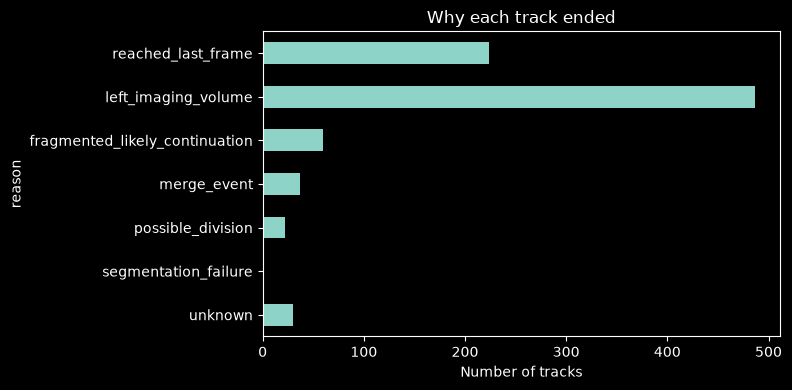

,track_id,last_frame,reason,daughter_a,daughter_b,candidate_track,median_volume,last_volume
0,1.0,0,left_imaging_volume,NaN,NaN,NaN,NaN,NaN
1,2.0,0,left_imaging_volume,NaN,NaN,NaN,NaN,NaN
2,7.0,0,left_imaging_volume,NaN,NaN,NaN,NaN,NaN
3,8.0,0,left_imaging_volume,NaN,NaN,NaN,NaN,NaN
4,9.0,0,left_imaging_volume,NaN,NaN,NaN,NaN,NaN
5,17.0,0,left_imaging_volume,NaN,NaN,NaN,NaN,NaN
6,20.0,0,left_imaging_volume,NaN,NaN,NaN,NaN,NaN
7,25.0,0,left_imaging_volume,NaN,NaN,NaN,NaN,NaN
8,26.0,0,left_imaging_volume,NaN,NaN,NaN,NaN,NaN
9,28.0,0,left_imaging_volume,NaN,NaN,NaN,NaN,NaN


In [133]:
# ------------------------------------------------------------
# Quick visual of the breakdown
# ------------------------------------------------------------

plt.figure(figsize=(8, 4))
summary.plot(kind="barh")
plt.xlabel("Number of tracks")
plt.title("Why each track ended")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

track_endings.head(20)

In [134]:
import napari

track_data = tracks[
    ["track_id", "frame", "z", "y", "x"]
].to_numpy()

viewer = napari.Viewer(ndisplay=3)

viewer.add_tracks(
    track_data,
    tail_length=20,
    head_length=0,
    name="Tracks",
)

viewer.add_points(
    tracks[["frame", "z", "y", "x"]].to_numpy(),
    size=3,
    face_color="red",
    name="Detections",
)

napari.run()

In [135]:
import zarr

ZARR_PATH = (
        DATA_ROOT
        / "biohub_5samples_20timepoints"
        / "train"
        / SAMPLE_ID
        / f"{SAMPLE_ID}.zarr"
)

ARRAY_PATH = ZARR_PATH / "0"

original_volume = zarr.open_array(
    str(ARRAY_PATH),
    mode="r"
)

In [136]:
import napari
import numpy as np

# ------------------------------------------------------------
# Convert tracks to Napari format
# ------------------------------------------------------------

tracks_array = tracks[
    ["track_id", "frame", "z", "y", "x"]
].to_numpy(dtype=float)

points_array = tracks[
    ["frame", "z", "y", "x"]
].to_numpy(dtype=float)

track_ids = tracks["track_id"].to_numpy()

# ------------------------------------------------------------
# Launch Napari
# ------------------------------------------------------------

viewer = napari.Viewer(ndisplay=3)

# Raw microscopy image
viewer.add_image(
    original_volume,
    name="Raw Volume",
    rendering="mip",          # Try "attenuated_mip" as well
    colormap="gray",
    contrast_limits=[
        np.percentile(original_volume, 1),
        np.percentile(original_volume, 99.8),
    ],
)

# Track trajectories
viewer.add_tracks(
    tracks_array,
    name="Tracks",
    tail_length=20,
)

# Cell centroids
viewer.add_points(
    points_array,
    name="Centroids",
    size=4,
    face_color="red",
    properties={
        "track_id": track_ids,
    },
)

napari.run()

Save results

In [137]:
output_dir = (
        DATA_ROOT
        / "processed"
        / "stage_8_cell_tracking"
)

In [138]:
import json

# ------------------------------------------------------------
# Save detections
# ------------------------------------------------------------

detections_df = pd.concat(
    detections,
    keys=range(len(detections)),
    names=["frame"],
).reset_index(level=0)

detections_df.to_csv(
    output_dir / "detections.csv",
    index=False,
)

# ------------------------------------------------------------
# Save tracks
# ------------------------------------------------------------

tracks.to_csv(
    output_dir / "tracks.csv",
    index=False,
)

# ------------------------------------------------------------
# Save segmentation events (candidate merges flagged in Stage 7B)
# ------------------------------------------------------------

segmentation_events.to_csv(
    output_dir / "segmentation_events.csv",
    index=False,
)

# ------------------------------------------------------------
# Save track termination classification
# ------------------------------------------------------------

track_endings.to_csv(
    output_dir / "track_endings.csv",
    index=False,
)

# ------------------------------------------------------------
# Save tracking parameters
# ------------------------------------------------------------

metadata = {
    "max_distance": MAX_DISTANCE,
    "distance_weight": W_DISTANCE,
    "volume_weight": W_VOLUME,
    "max_volume_ratio": MAX_VOLUME_RATIO,
    "motion_compensation": True,
    "global_motion_estimator": "median (iteratively refined on matched pairs)",
    "gap_closing": True,
    "max_gap": MAX_GAP,
    "stitch_max_distance": STITCH_MAX_DISTANCE,
    "stitch_max_volume_ratio": STITCH_MAX_VOLUME_RATIO,
    "merge_detection": True,
    "merge_max_distance": MERGE_MAX_DISTANCE,
    "merge_volume_tolerance": MERGE_VOLUME_TOLERANCE,
}

with open(output_dir / "metadata.json", "w") as f:
    json.dump(metadata, f, indent=4)

print(f"Saved Stage 7 results to: {output_dir}")

Saved Stage 7 results to: D:\Projects\Kaggle\cell-tracking\data\sample\processed\stage_8_cell_tracking
